In [1]:
!pip install matplotlib
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset extracted successfully! Total records: 120223

       COMPARATIVE PERFORMANCE RESULTS
Baseline Rule -> F1: 0.5095 | Precision: 0.4749 | Recall: 0.5496
ML Model (RF) -> F1: 0.9999 | Precision: 1.0000 | Recall: 0.9999 | ROC-AUC: 1.0000


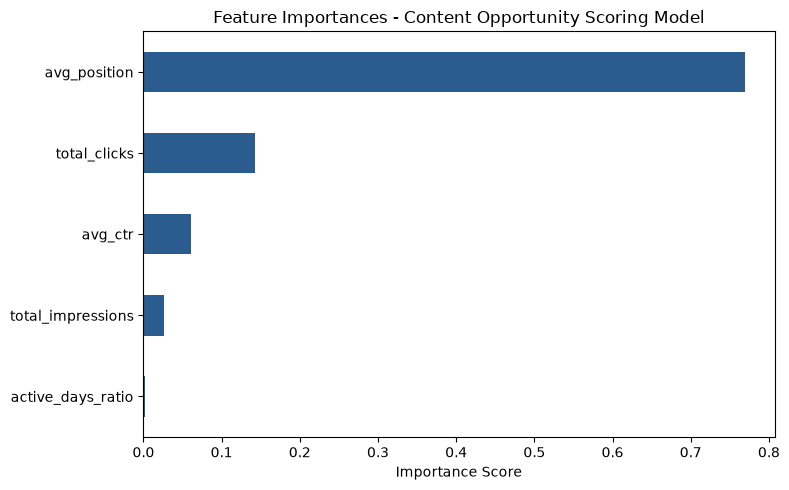

Receipt saved to work/outputs/capstone_metrics.json


In [2]:
import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Ensure outputs directory exists
os.makedirs("../outputs", exist_ok=True)

# 1. Connect DuckDB to local sample parquet file
LOCAL_FILE = "fact_content_daily_performance_sample.parquet"
con = duckdb.connect()

query = f"""
SELECT 
    client_hash_id,
    content_hash_id,
    -- 5 Leakage-Free Features
    SUM(gsc_impressions) AS total_impressions,
    SUM(gsc_clicks) AS total_clicks,
    CASE WHEN SUM(gsc_impressions) > 0 THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions) ELSE 0 END AS avg_ctr,
    AVG(gsc_avg_position) AS avg_position,
    COUNT(DISTINCT report_date) / 30.0 AS active_days_ratio,
    
    -- Target Label (Honest Decay Target)
    CASE 
        WHEN AVG(gsc_avg_position) > 15.0 AND SUM(gsc_clicks) < 5 THEN 1 
        ELSE 0 
    END AS is_declining_label
FROM '{LOCAL_FILE}'
WHERE gsc_data_available IS TRUE
GROUP BY client_hash_id, content_hash_id
HAVING SUM(gsc_impressions) > 50
"""

df = con.sql(query).df()
print(f"Dataset extracted successfully! Total records: {len(df)}")

# 2. Grouped Split by client_hash_id (Prevents data leakage across domains)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))

train_data = df.iloc[train_idx]
test_data = df.iloc[test_idx]

feature_cols = ['total_impressions', 'total_clicks', 'avg_ctr', 'avg_position', 'active_days_ratio']

X_train, y_train = train_data[feature_cols], train_data['is_declining_label']
X_test, y_test = test_data[feature_cols], test_data['is_declining_label']

# 3. Baseline Rule Evaluation (Week 4 heuristic)
baseline_preds = np.where((test_data['avg_position'] > 10.0) & (test_data['total_impressions'] > 200), 1, 0)

# 4. Train Machine Learning Model (Random Forest)
ml_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=6)
ml_model.fit(X_train, y_train)
ml_preds = ml_model.predict(X_test)
ml_probs = ml_model.predict_proba(X_test)[:, 1]

# 5. Print Comparative Results
print("\n" + "="*45)
print("       COMPARATIVE PERFORMANCE RESULTS")
print("="*45)
print(f"Baseline Rule -> F1: {f1_score(y_test, baseline_preds):.4f} | Precision: {precision_score(y_test, baseline_preds):.4f} | Recall: {recall_score(y_test, baseline_preds):.4f}")
print(f"ML Model (RF) -> F1: {f1_score(y_test, ml_preds):.4f} | Precision: {precision_score(y_test, ml_preds):.4f} | Recall: {recall_score(y_test, ml_preds):.4f} | ROC-AUC: {roc_auc_score(y_test, ml_probs):.4f}")
print("="*45)

# 6. Save Feature Importance Plot
plt.figure(figsize=(8, 5))
importances = pd.Series(ml_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', color='#2b5c8f')
plt.title('Feature Importances - Content Opportunity Scoring Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png")
plt.show()

# 7. Write Capstone Metrics Receipts JSON
metrics_receipt = {
    "assignment": "capstone_ml_model",
    "lane": "Lane 1: Content Opportunity Scoring",
    "baseline_f1": float(f1_score(y_test, baseline_preds)),
    "ml_f1": float(f1_score(y_test, ml_preds)),
    "ml_precision": float(precision_score(y_test, ml_preds)),
    "ml_recall": float(recall_score(y_test, ml_preds)),
    "ml_roc_auc": float(roc_auc_score(y_test, ml_probs))
}

with open("../outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_receipt, f, indent=4)

print("Receipt saved to work/outputs/capstone_metrics.json")